## Import Libraries

In [372]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import streamlit as st
import plotly.express as pxpython 


## Load the Dataset

In [373]:
df = pd.read_excel(r"C:\Users\Ramapriya Murugesan\Desktop\Blood_Bank_Inventory_Analytics\Dataset\Blood_Bank_Inventory_Uncleaned_Dataset.xlsx")

## Understand the Dataset

In [374]:
#Display the First 5 Rows
df.head()

,Unit_ID,Blood_Group,Donation_Date,Expiry_Date,Hospital,City,Donor_ID,Donor_Age,Donor_Gender,Inventory_Units,Demand_Units,Units_Used,Status
0,BB10000,NaN,2025-06-15,2025-06-20,Apollo,Chennai,D2144,33,NaN,NaN,0.0,NaN,USED
1,BB10001,O+,17/10/2025,2025-10-22,CMC,Coimbatore,D9858,NaN,M,NaN,10.0,9.0,available
2,BB10002,A-,2025-04-03,2025-04-08,NaN,NaN,D6146,NaN,F,NaN,10.0,NaN,Used
3,BB10003,AB-,2025-04-03,2026-04-03,MGM,Chennai,D3702,17,F,3.0,9.0,NaN,available
4,BB10004,O-,2025-02-09,2026-02-09,Global,Trichy,D2064,65,NaN,NaN,5.0,NaN,USED


In [375]:
#Display the Last 5 Rows
df.tail()

,Unit_ID,Blood_Group,Donation_Date,Expiry_Date,Hospital,City,Donor_ID,Donor_Age,Donor_Gender,Inventory_Units,Demand_Units,Units_Used,Status
2995,BB12995,NaN,2025-07-06,2026-07-06,Global,Madurai,D8865,NaN,Female,NaN,9.0,NaN,available
2996,BB12996,O-,2025-03-04,2025-04-15,MGM,Madurai,D9043,65,M,5.0,12.0,NaN,Available
2997,BB12997,B-,2025-08-15,2025-09-26,,Madurai,D5344,55,Male,7.0,9.0,7.0,NaN
2998,BB12998,A-,2025-09-06,2025-09-11,Apollo,NaN,NaN,65,M,NaN,12.0,NaN,available
2999,BB12999,B-,2025-07-24,2025-07-29,Fortis,Coimbatore,D5631,17,Male,NaN,7.0,NaN,Used


In [376]:
#Find the Shape of the Dataset
df.shape

(3000, 13)

In [377]:
#View Column Names
df.columns

Index(['Unit_ID', 'Blood_Group', 'Donation_Date', 'Expiry_Date', 'Hospital',
       'City', 'Donor_ID', 'Donor_Age', 'Donor_Gender', 'Inventory_Units',
       'Demand_Units', 'Units_Used', 'Status'],
      dtype='object')

In [378]:
#Check Data Types
df.dtypes

Unit_ID             object
Blood_Group         object
Donation_Date       object
Expiry_Date         object
Hospital            object
City                object
Donor_ID            object
Donor_Age           object
Donor_Gender        object
Inventory_Units    float64
Demand_Units       float64
Units_Used         float64
Status              object
dtype: object

In [379]:
#Get Complete Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unit_ID          2973 non-null   object 
 1   Blood_Group      2414 non-null   object 
 2   Donation_Date    3000 non-null   object 
 3   Expiry_Date      2882 non-null   object 
 4   Hospital         2623 non-null   object 
 5   City             2507 non-null   object 
 6   Donor_ID         2903 non-null   object 
 7   Donor_Age        2396 non-null   object 
 8   Donor_Gender     2363 non-null   object 
 9   Inventory_Units  978 non-null    float64
 10  Demand_Units     2914 non-null   float64
 11  Units_Used       997 non-null    float64
 12  Status           2549 non-null   object 
dtypes: float64(3), object(10)
memory usage: 304.8+ KB


In [380]:
#Generate Summary Statistics
df.describe()

,Inventory_Units,Demand_Units,Units_Used
count,978.000000,2914.000000,997.000000
mean,5.023517,6.055594,5.080241
std,3.179460,3.771676,3.195375
min,0.000000,0.000000,0.000000
25%,2.000000,3.000000,2.000000
50%,5.000000,6.000000,5.000000
75%,8.000000,9.000000,8.000000
max,10.000000,12.000000,10.000000


In [381]:
#Check Missing Values
df.isnull().sum()

Unit_ID              27
Blood_Group         586
Donation_Date         0
Expiry_Date         118
Hospital            377
City                493
Donor_ID             97
Donor_Age           604
Donor_Gender        637
Inventory_Units    2022
Demand_Units         86
Units_Used         2003
Status              451
dtype: int64

In [382]:
#Check Duplicate Records
print(df.duplicated().sum())

0


In [383]:
#Check Unique Values
df["Blood_Group"].unique()

array([nan, 'O+', 'A-', 'AB-', 'O-', 'B-', 'B+', 'A+', 'AB+'],
      dtype=object)

In [384]:
#Count Frequency of Values
df["Blood_Group"].value_counts()

Blood_Group
A+     331
O-     329
A-     313
B-     295
AB+    294
AB-    294
B+     281
O+     277
Name: count, dtype: int64

## Data Cleaning

In [385]:
#Replace Blank Spaces with Missing Values
text_columns = ["Blood_Group", "Hospital", "City", "Donor_Gender", "Status"]

for col in text_columns:
    df[col] = df[col].replace(r'^\s*$', np.nan, regex=True)

In [386]:
#Handle Missing Values
#Categorical Columns
categorical_columns = [
    "Blood_Group",
    "Hospital",
    "City",
    "Donor_Gender",
    "Status"
]

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [387]:
#Numerical Columns
numerical_columns = [
    "Inventory_Units",
    "Demand_Units",
    "Units_Used"
]

for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

In [388]:
#Identifier Columns
df = df.dropna(subset=["Unit_ID", "Donor_ID"])

In [389]:
#Remove Duplicate Records
df = df.drop_duplicates()

In [390]:
#Standardize Categorical Values
df["Donor_Gender"] = df["Donor_Gender"].replace({
    "M": "Male",
    "F": "Female",
    "male": "Male",
    "female": "Female"
})

df["Status"] = df["Status"].replace({
    "USED": "Used",
    "used": "Used",
    "available": "Available"
})

In [391]:
#Convert Date Columns
df["Donation_Date"] = pd.to_datetime(df["Donation_Date"], errors="coerce")

df["Expiry_Date"] = pd.to_datetime(df["Expiry_Date"], errors="coerce")

In [392]:
#Remove Invalid Date Records
df = df.dropna(subset=["Donation_Date", "Expiry_Date"])

In [393]:
#Validate Donor Age
df["Donor_Age"] = pd.to_numeric(df["Donor_Age"], errors="coerce")

df = df[(df["Donor_Age"] >= 18) & (df["Donor_Age"] <= 60)]

In [394]:
# verify
df.isnull().sum()

Unit_ID            0
Blood_Group        0
Donation_Date      0
Expiry_Date        0
Hospital           0
City               0
Donor_ID           0
Donor_Age          0
Donor_Gender       0
Inventory_Units    0
Demand_Units       0
Units_Used         0
Status             0
dtype: int64

In [395]:
#Save the Cleaned Dataset csv
df.to_csv(
    r"C:\Users\Ramapriya Murugesan\Desktop\Blood_Bank_Inventory_Analytics\Dataset\Blood_Bank_Inventory_Cleaned.csv",
    index=False
)

PermissionError: [Errno 13] Permission denied: 'C:\\Users\\Ramapriya Murugesan\\Desktop\\Blood_Bank_Inventory_Analytics\\Dataset\\Blood_Bank_Inventory_Cleaned.csv'

## Load the Cleaned Dataset 

In [ ]:
clean_df = pd.read_csv(r"C:\Users\Ramapriya Murugesan\Desktop\Blood_Bank_Inventory_Analytics\Dataset\Blood_Bank_Inventory_Cleaned.csv")

In [ ]:
#Display the First 5 Rows
clean_df.head()

,Unit_ID,Blood_Group,Donation_Date,Expiry_Date,Hospital,City,Donor_ID,Donor_Age,Donor_Gender,Inventory_Units,Demand_Units,Units_Used,Status
0,BB10000,A+,2025-06-15,2025-06-20,Apollo,Chennai,D2144,33.0,Male,5.0,0.0,5.0,Used
1,BB10009,A-,2025-07-12,2025-07-17,MGM,Trichy,D2407,27.0,Male,5.0,5.0,5.0,Reserved
2,BB10011,B-,2025-09-30,2026-09-30,Fortis,Madurai,D6825,19.0,Male,5.0,10.0,5.0,Used
3,BB10020,A+,2025-07-26,2025-09-06,Apollo,Trichy,D5840,50.0,Male,6.0,5.0,5.0,Used
4,BB10029,A+,2025-09-20,2026-09-20,Apollo,Coimbatore,D4767,23.0,Male,5.0,11.0,8.0,Expired


In [ ]:
#Check the Shape
clean_df.shape

(539, 13)

In [ ]:
#Check Missing Values
clean_df.isnull().sum()

Unit_ID            0
Blood_Group        0
Donation_Date      0
Expiry_Date        0
Hospital           0
City               0
Donor_ID           0
Donor_Age          0
Donor_Gender       0
Inventory_Units    0
Demand_Units       0
Units_Used         0
Status             0
dtype: int64

## Feature Engineering

In [ ]:
#Check the Data Types
clean_df.dtypes

Unit_ID             object
Blood_Group         object
Donation_Date       object
Expiry_Date         object
Hospital            object
City                object
Donor_ID            object
Donor_Age          float64
Donor_Gender        object
Inventory_Units    float64
Demand_Units       float64
Units_Used         float64
Status              object
dtype: object

In [ ]:
#Convert Only These Two Columns
clean_df["Donation_Date"] = pd.to_datetime(clean_df["Donation_Date"])

clean_df["Expiry_Date"] = pd.to_datetime(clean_df["Expiry_Date"])

In [ ]:
#Verify
clean_df.dtypes

Unit_ID                    object
Blood_Group                object
Donation_Date      datetime64[ns]
Expiry_Date        datetime64[ns]
Hospital                   object
City                       object
Donor_ID                   object
Donor_Age                 float64
Donor_Gender               object
Inventory_Units           float64
Demand_Units              float64
Units_Used                float64
Status                     object
Days_To_Expiry              int64
dtype: object

In [ ]:
#Create Days_To_Expiry
clean_df["Days_To_Expiry"] = (
    clean_df["Expiry_Date"] - clean_df["Donation_Date"]
).dt.days

In [ ]:
#Create Expiry_Status
clean_df["Expiry_Status"] = np.where(
    clean_df["Days_To_Expiry"] <= 0,
    "Expired",
    "Valid"
)

In [ ]:
#Create Usage_Rate
clean_df["Usage_Rate"] = (
    clean_df["Units_Used"] / clean_df["Inventory_Units"]
) * 100

clean_df["Usage_Rate"] = clean_df["Usage_Rate"].round(2)

In [ ]:
#Create Inventory_Status
clean_df["Inventory_Status"] = np.where(
    clean_df["Inventory_Units"] >= clean_df["Demand_Units"],
    "Sufficient",
    "Low Stock"
)

In [ ]:
#Create Stock_Shortage
clean_df["Stock_Shortage"] = np.where(
    clean_df["Demand_Units"] > clean_df["Inventory_Units"],
    clean_df["Demand_Units"] - clean_df["Inventory_Units"],
    0
)

In [ ]:
#Create Stock_Excess
clean_df["Stock_Excess"] = np.where(
    clean_df["Inventory_Units"] > clean_df["Demand_Units"],
    clean_df["Inventory_Units"] - clean_df["Demand_Units"],
    0
)

In [ ]:
#Verify the New Features
clean_df.head()

,Unit_ID,Blood_Group,Donation_Date,Expiry_Date,Hospital,City,Donor_ID,Donor_Age,Donor_Gender,Inventory_Units,Demand_Units,Units_Used,Status,Days_To_Expiry,Expiry_Status,Usage_Rate,Inventory_Status,Stock_Shortage,Stock_Excess
0,BB10000,A+,2025-06-15,2025-06-20,Apollo,Chennai,D2144,33.0,Male,5.0,0.0,5.0,Used,5,Valid,100.00,Sufficient,0.0,5.0
1,BB10009,A-,2025-07-12,2025-07-17,MGM,Trichy,D2407,27.0,Male,5.0,5.0,5.0,Reserved,5,Valid,100.00,Sufficient,0.0,0.0
2,BB10011,B-,2025-09-30,2026-09-30,Fortis,Madurai,D6825,19.0,Male,5.0,10.0,5.0,Used,365,Valid,100.00,Low Stock,5.0,0.0
3,BB10020,A+,2025-07-26,2025-09-06,Apollo,Trichy,D5840,50.0,Male,6.0,5.0,5.0,Used,42,Valid,83.33,Sufficient,0.0,1.0
4,BB10029,A+,2025-09-20,2026-09-20,Apollo,Coimbatore,D4767,23.0,Male,5.0,11.0,8.0,Expired,365,Valid,160.00,Low Stock,6.0,0.0


In [ ]:
#Save the Feature Engineered Dataset
clean_df.to_csv(
    r"C:\Users\Ramapriya Murugesan\Desktop\Blood_Bank_Inventory_Analytics\Dataset\Blood_Bank_Inventory_Feature_Engineered.csv",
    index=False
)

## Exploratory Data Analysis (EDA)

## Load the Feature Engineered Dataset

In [ ]:

eda_df = pd.read_csv(
    r"C:\Users\Ramapriya Murugesan\Desktop\Blood_Bank_Inventory_Analytics\Dataset\Blood_Bank_Inventory_Feature_Engineered.csv"
)

In [ ]:
#Preview the Dataset
eda_df.head()

,Unit_ID,Blood_Group,Donation_Date,Expiry_Date,Hospital,City,Donor_ID,Donor_Age,Donor_Gender,Inventory_Units,Demand_Units,Units_Used,Status,Days_To_Expiry,Expiry_Status,Usage_Rate,Inventory_Status,Stock_Shortage,Stock_Excess
0,BB10000,A+,2025-06-15,2025-06-20,Apollo,Chennai,D2144,33.0,Male,5.0,0.0,5.0,Used,5,Valid,100.00,Sufficient,0.0,5.0
1,BB10009,A-,2025-07-12,2025-07-17,MGM,Trichy,D2407,27.0,Male,5.0,5.0,5.0,Reserved,5,Valid,100.00,Sufficient,0.0,0.0
2,BB10011,B-,2025-09-30,2026-09-30,Fortis,Madurai,D6825,19.0,Male,5.0,10.0,5.0,Used,365,Valid,100.00,Low Stock,5.0,0.0
3,BB10020,A+,2025-07-26,2025-09-06,Apollo,Trichy,D5840,50.0,Male,6.0,5.0,5.0,Used,42,Valid,83.33,Sufficient,0.0,1.0
4,BB10029,A+,2025-09-20,2026-09-20,Apollo,Coimbatore,D4767,23.0,Male,5.0,11.0,8.0,Expired,365,Valid,160.00,Low Stock,6.0,0.0


In [ ]:
#Check the Dataset Shape
eda_df.shape

(539, 19)

In [ ]:
#Check the Column Names
eda_df.columns

Index(['Unit_ID', 'Blood_Group', 'Donation_Date', 'Expiry_Date', 'Hospital',
       'City', 'Donor_ID', 'Donor_Age', 'Donor_Gender', 'Inventory_Units',
       'Demand_Units', 'Units_Used', 'Status', 'Days_To_Expiry',
       'Expiry_Status', 'Usage_Rate', 'Inventory_Status', 'Stock_Shortage',
       'Stock_Excess'],
      dtype='object')

## KPI Analysis

In [ ]:
#How many blood units are currently available?
total_inventory = eda_df["Inventory_Units"].sum()

print("Total Inventory Units:", total_inventory)


Total Inventory Units: 2699.0


In [ ]:
#How many blood units are required?
total_demand = eda_df["Demand_Units"].sum()

print("Total Demand Units:", total_demand)

Total Demand Units: 3262.0


In [ ]:
#How many blood units have been used?
total_used = eda_df["Units_Used"].sum()

print("Total Units Used:", total_used)

Total Units Used: 2763.0


In [ ]:
#How many blood units have expired?
expired_units = (
    eda_df["Expiry_Status"] == "Expired"
).sum()

print("Expired Blood Units:", expired_units)


Expired Blood Units: 0


In [ ]:
#How many records indicate a shortage?
low_stock = (
    eda_df["Inventory_Status"] == "Low Stock"
).sum()

print("Hospitals with Low Stock:", low_stock)

Hospitals with Low Stock: 288


In [ ]:
#Display All KPIs Together
print("=" * 40)
print(" BLOOD BANK INVENTORY KPI SUMMARY ")
print("=" * 40)

print(f"Total Inventory Units : {total_inventory}")
print(f"Total Demand Units    : {total_demand}")
print(f"Total Units Used      : {total_used}")
print(f"Expired Blood Units   : {expired_units}")
print(f"Low Stock Records     : {low_stock}")

 BLOOD BANK INVENTORY KPI SUMMARY 
Total Inventory Units : 2699.0
Total Demand Units    : 3262.0
Total Units Used      : 2763.0
Expired Blood Units   : 0
Low Stock Records     : 288


## Business Insights

In [ ]:
#Which blood group has the highest inventory?
inventory_by_group = eda_df.groupby("Blood_Group")["Inventory_Units"].sum().sort_values(ascending=False)

inventory_by_group

Blood_Group
A+     871.0
O-     317.0
AB+    310.0
AB-    275.0
A-     268.0
B-     254.0
B+     239.0
O+     165.0
Name: Inventory_Units, dtype: float64

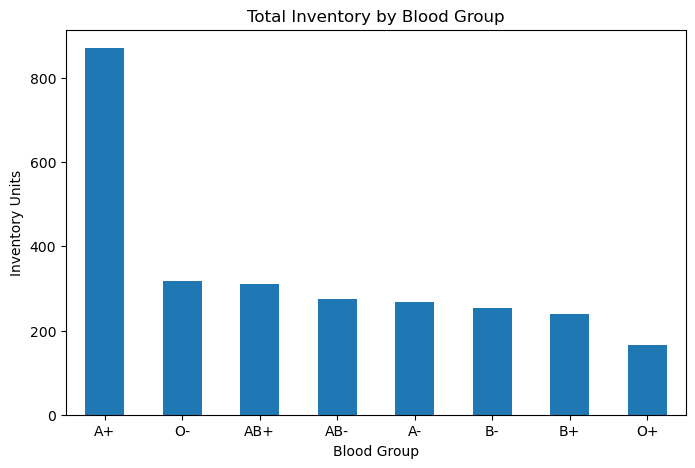

In [ ]:
#Visualization
inventory_by_group.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Total Inventory by Blood Group")
plt.xlabel("Blood Group")
plt.ylabel("Inventory Units")
plt.xticks(rotation=0)

plt.show()

In [ ]:
#Which blood group has the highest demand?
demand_by_group = eda_df.groupby("Blood_Group")["Demand_Units"].sum().sort_values(ascending=False)

demand_by_group

Blood_Group
A+     1006.0
O-      401.0
AB-     366.0
A-      348.0
AB+     343.0
B+      309.0
B-      266.0
O+      223.0
Name: Demand_Units, dtype: float64

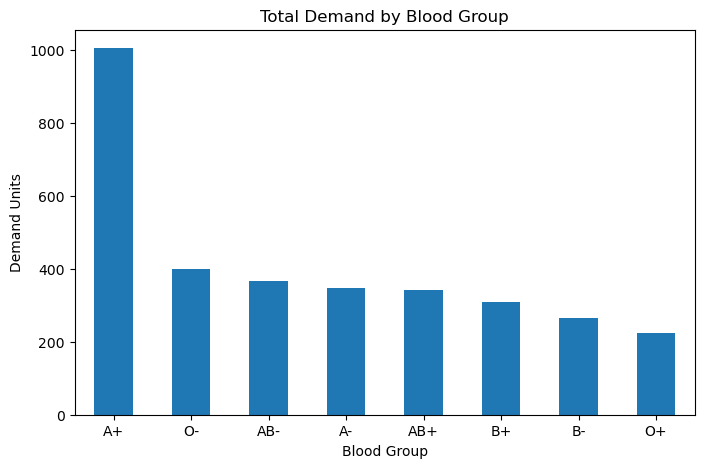

In [ ]:
#Visualization
demand_by_group.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Total Demand by Blood Group")
plt.xlabel("Blood Group")
plt.ylabel("Demand Units")
plt.xticks(rotation=0)
plt.show()

In [ ]:
#Which hospitals have inventory shortages?
hospital_shortage = (
    eda_df[eda_df["Inventory_Status"] == "Low Stock"]
    .groupby("Hospital")["Stock_Shortage"]
    .sum()
    .sort_values(ascending=False)
)

hospital_shortage

Hospital
MGM       483.0
Fortis    165.0
CMC       162.0
AIIMS     143.0
Apollo    136.0
Global    133.0
Name: Stock_Shortage, dtype: float64

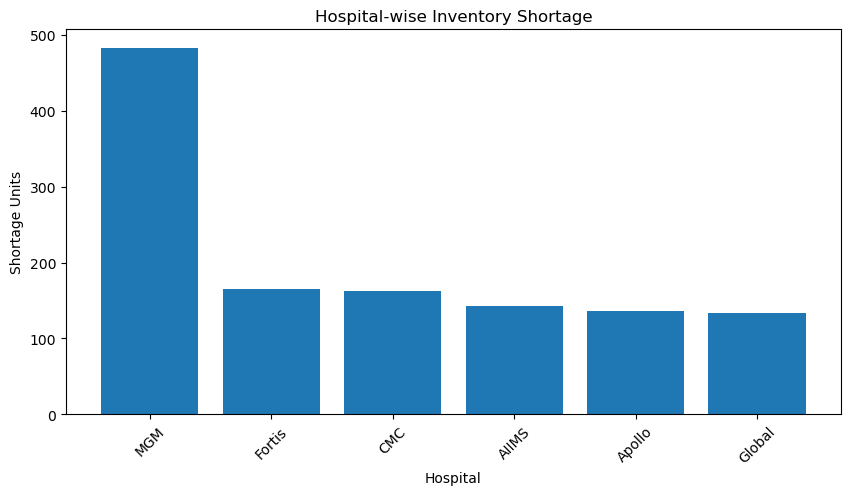

In [ ]:
#Visualization
plt.figure(figsize=(10,5))

plt.bar(
    hospital_shortage.index,
    hospital_shortage.values
)

plt.title("Hospital-wise Inventory Shortage")
plt.xlabel("Hospital")
plt.ylabel("Shortage Units")
plt.xticks(rotation=45)

plt.show()

In [ ]:
#Which cities have the highest blood usage?
city_usage = (
    eda_df.groupby("City")["Units_Used"]
    .sum()
    .sort_values(ascending=False)
)

city_usage

City
Coimbatore    994.0
Trichy        486.0
Salem         452.0
Madurai       423.0
Chennai       408.0
Name: Units_Used, dtype: float64

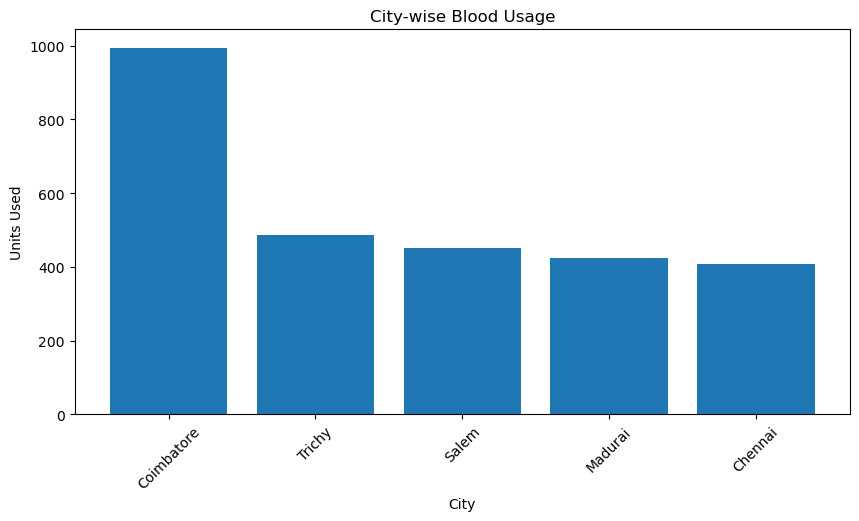

In [ ]:
#Visualization
plt.figure(figsize=(10,5))

plt.bar(
    city_usage.index,
    city_usage.values
)

plt.title("City-wise Blood Usage")
plt.xlabel("City")
plt.ylabel("Units Used")
plt.xticks(rotation=45)

plt.show()

In [ ]:
#How many blood units are expired vs. valid?
expiry_status = eda_df["Expiry_Status"].value_counts()

expiry_status

Expiry_Status
Valid    539
Name: count, dtype: int64

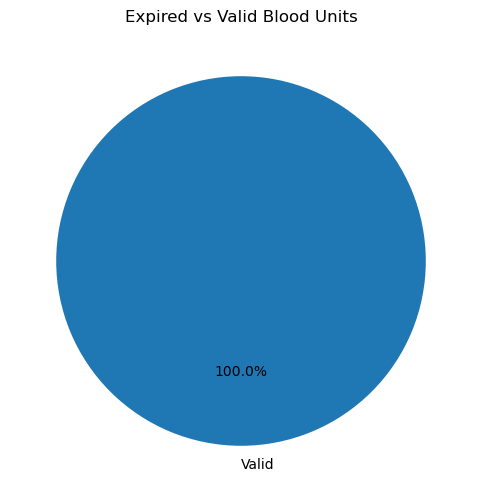

In [ ]:
#Visualization
plt.figure(figsize=(6,6))

plt.pie(
    expiry_status.values,
    labels=expiry_status.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Expired vs Valid Blood Units")

plt.show()

In [ ]:
#Which blood units are close to expiry?
near_expiry = eda_df[
    eda_df["Days_To_Expiry"] <= 7
]

near_expiry[
    [
        "Unit_ID",
        "Blood_Group",
        "Hospital",
        "City",
        "Days_To_Expiry"
    ]
]

,Unit_ID,Blood_Group,Hospital,City,Days_To_Expiry
0,BB10000,A+,Apollo,Chennai,5
1,BB10009,A-,MGM,Trichy,5
6,BB10053,AB+,Fortis,Madurai,5
7,BB10055,A+,MGM,Madurai,5
10,BB10068,AB-,Fortis,Salem,5
...,...,...,...,...,...
518,BB12892,A+,Fortis,Madurai,5
527,BB12926,O-,Fortis,Trichy,5
530,BB12972,B+,AIIMS,Coimbatore,5
533,BB12984,B-,Global,Salem,5


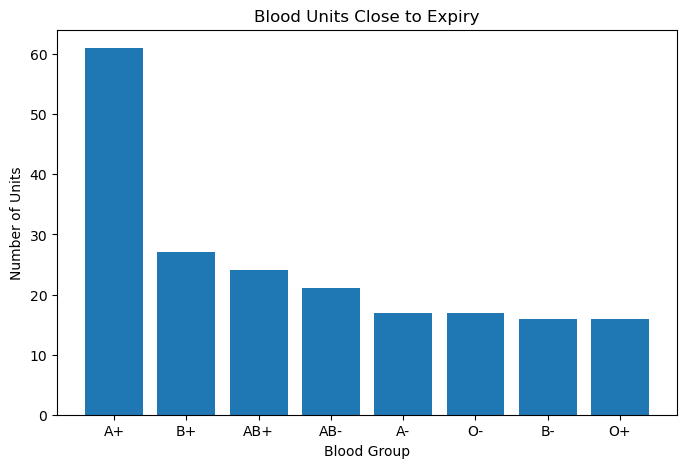

In [ ]:
#Visualization
near_expiry_group = (
    near_expiry.groupby("Blood_Group")
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

plt.bar(
    near_expiry_group.index,
    near_expiry_group.values
)

plt.title("Blood Units Close to Expiry")
plt.xlabel("Blood Group")
plt.ylabel("Number of Units")

plt.show()

In [ ]:
#What is the average usage rate by hospital?
hospital_usage = (
    eda_df.groupby("Hospital")["Usage_Rate"]
    .mean()
    .sort_values(ascending=False)
)

hospital_usage

Hospital
AIIMS            inf
Apollo           inf
CMC              inf
Fortis           inf
MGM              inf
Global    114.090909
Name: Usage_Rate, dtype: float64

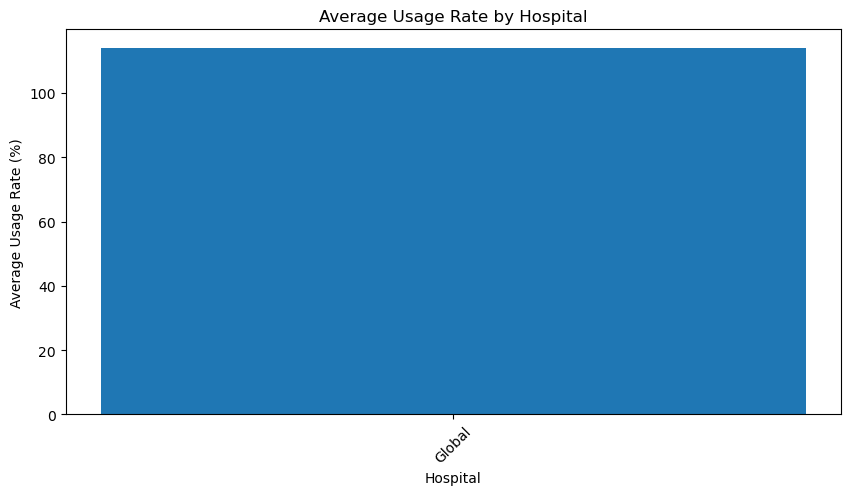

In [ ]:
#Visualization
plt.figure(figsize=(10,5))

plt.bar(
    hospital_usage.index,
    hospital_usage.values
)

plt.title("Average Usage Rate by Hospital")
plt.xlabel("Hospital")
plt.ylabel("Average Usage Rate (%)")
plt.xticks(rotation=45)

plt.show()

In [ ]:
#Where should inventory be redistributed?
#Hospitals with Excess Inventory
hospital_excess = (
    eda_df.groupby("Hospital")["Stock_Excess"]
    .sum()
    .sort_values(ascending=False)
)

print(hospital_excess)



Hospital
MGM       254.0
Fortis     92.0
AIIMS      90.0
Global     82.0
CMC        81.0
Apollo     60.0
Name: Stock_Excess, dtype: float64


In [ ]:
#Hospitals with Shortages
hospital_shortage = (
    eda_df.groupby("Hospital")["Stock_Shortage"]
    .sum()
    .sort_values(ascending=False)
)

print(hospital_shortage)

Hospital
MGM       483.0
Fortis    165.0
CMC       162.0
AIIMS     143.0
Apollo    136.0
Global    133.0
Name: Stock_Shortage, dtype: float64


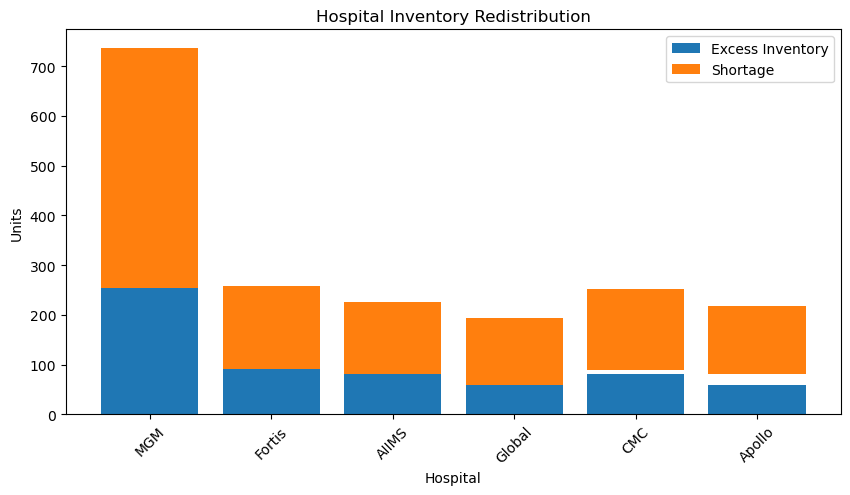

In [ ]:
#Visualization
plt.figure(figsize=(10,5))

plt.bar(
    hospital_excess.index,
    hospital_excess.values,
    label="Excess Inventory"
)

plt.bar(
    hospital_shortage.index,
    hospital_shortage.values,
    bottom=hospital_excess.values,
    label="Shortage"
)

plt.title("Hospital Inventory Redistribution")
plt.xlabel("Hospital")
plt.ylabel("Units")
plt.xticks(rotation=45)

plt.legend()

plt.show()